In [38]:
import pandas as pd
import matplotlib.pyplot as plt
netflix_data = pd.read_csv('./data/netflix_titles.csv')
netflix_data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [39]:
netflix_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


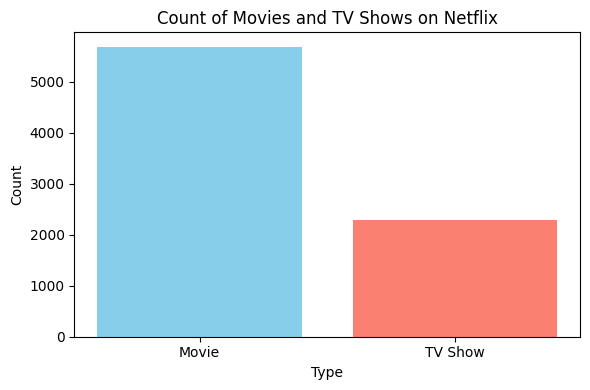

In [40]:
# Droping Null values
netflix_data = netflix_data.dropna(subset=['type','release_year','rating','duration','country'])
type_count = netflix_data['type'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(type_count.index, type_count.values, color = ['skyblue','salmon'])
plt.title('Count of Movies and TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('Count of shows and movies.png')

plt.show()



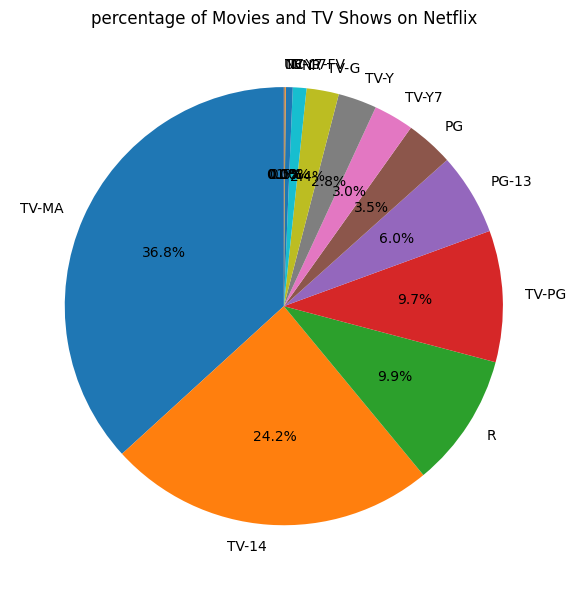

In [41]:
rating_count = netflix_data['rating'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(rating_count,labels=rating_count.index,autopct='%1.1f%%',startangle=90)
plt.title('percentage of Movies and TV Shows on Netflix')

plt.tight_layout()
plt.savefig('rating_distribution.png')

plt.show()


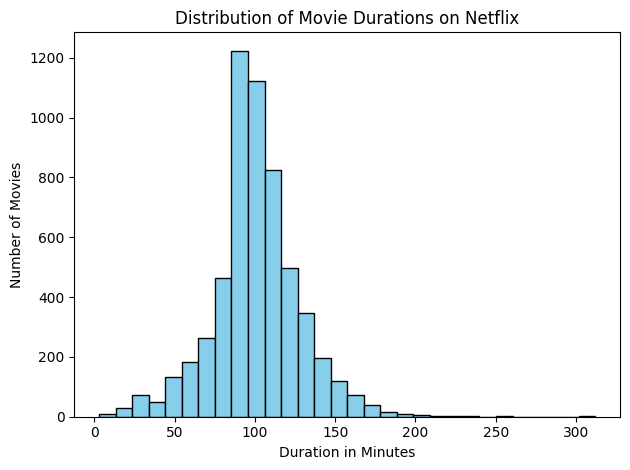

In [42]:
movie_data = netflix_data[netflix_data['type'] == 'Movie'].copy()
movie_data['duration'] = movie_data['duration'].str.replace('min','').astype(int)
plt.Figure(figsize=(8,6))
plt.hist(movie_data['duration'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Movie Durations on Netflix')
plt.xlabel('Duration in Minutes')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('movie_duration_distribution.png')
plt.show()

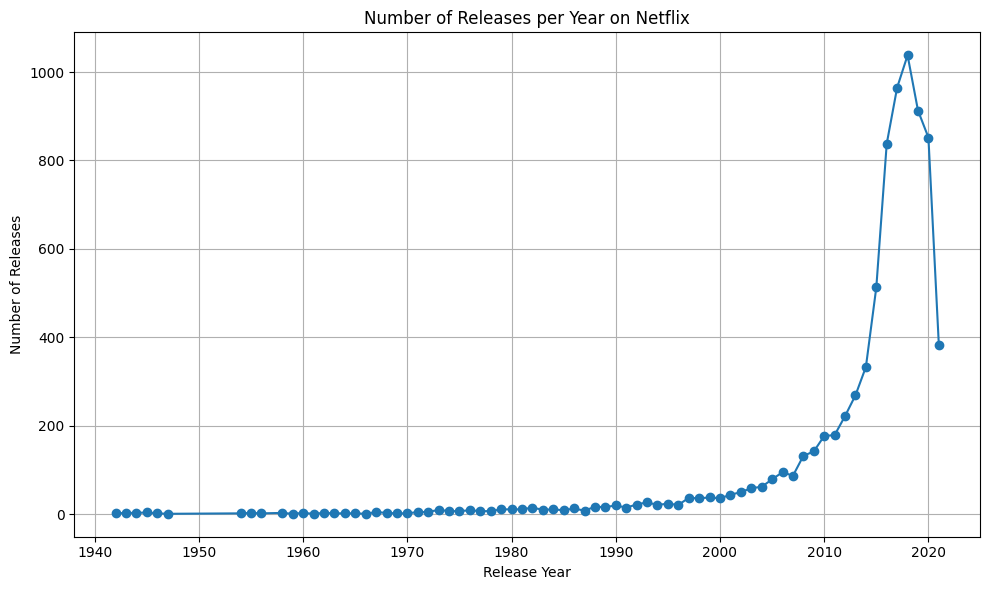

In [43]:
release_year_count = netflix_data['release_year'].value_counts().sort_index()
plt.figure(figsize=(10,6))
plt.plot(release_year_count.index, release_year_count.values, marker='o', linestyle='-')
plt.title('Number of Releases per Year on Netflix')
plt.xlabel('Release Year')
plt.ylabel('Number of Releases')
plt.grid()
plt.tight_layout()
plt.savefig('releases_per_year.png')
plt.show()

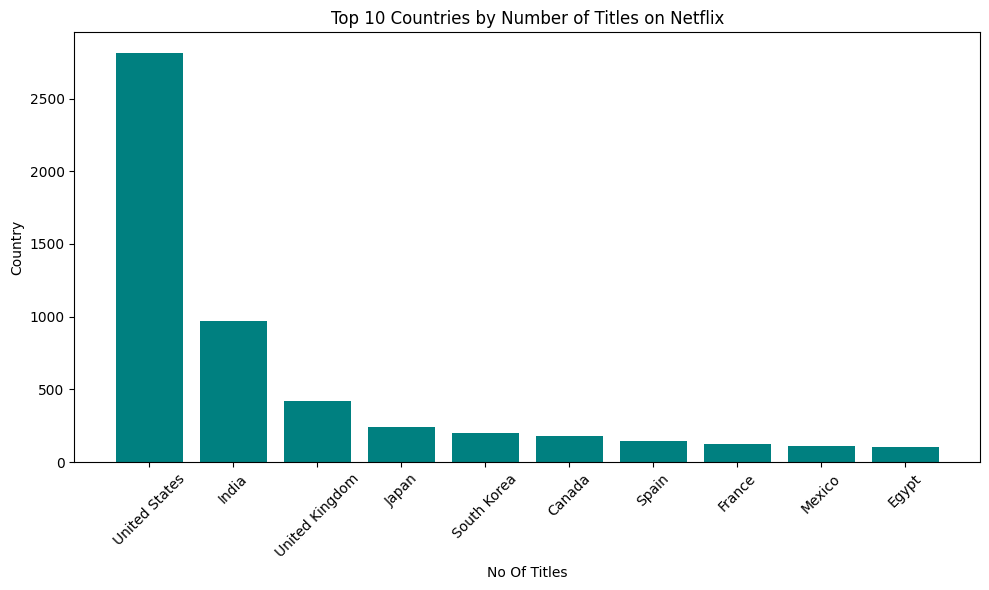

In [44]:
country_count = netflix_data['country'].value_counts().head(10)
plt.figure(figsize=(10,6))
plt.bar(country_count.index, country_count.values, color='teal')
plt.title('Top 10 Countries by Number of Titles on Netflix')
plt.xlabel('No Of Titles')
plt.ylabel('Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_countries.png')
plt.show()

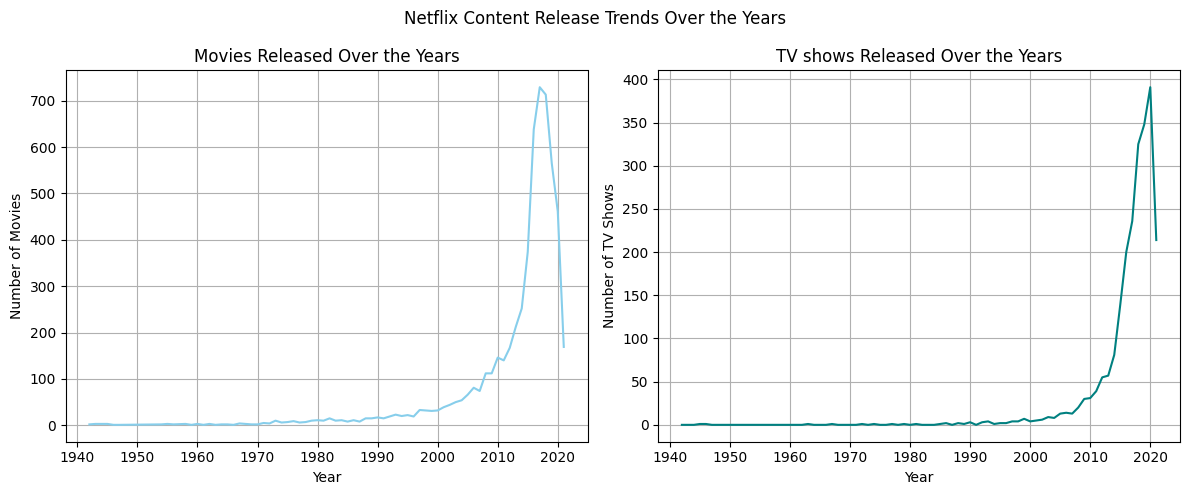

In [45]:

content_by_year = netflix_data.groupby(['release_year','type']).size().unstack().fillna(0)
fig, ax = plt.subplots(1,2, figsize = (12,5))
# First subplot for Movies
ax[0].plot(content_by_year.index, content_by_year['Movie'], color='skyblue')
ax[0].set_title('Movies Released Over the Years')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of Movies')
ax[0].grid()
# Second subplot for TV Shows
ax[1].plot(content_by_year.index, content_by_year['TV Show'], color='teal')
ax[1].set_title('TV shows Released Over the Years')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Number of TV Shows')
ax[1].grid()
fig.suptitle('Netflix Content Release Trends Over the Years')

plt.savefig('content_release_trends.png')
plt.tight_layout()
plt.show()


